<a href="https://colab.research.google.com/github/naiaraaltuna/everpeak-analysis/blob/main/preparacion_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis estadístico para detectar patrones y outliers I 🐍🖥️✍️

## Objetivos academicos

- Manejar valores ausentes o no válidos con python
- Uso de ciclos en python
- Crear funciones en python.
- Crear pipeline de datos con python.


## Práctica guiada: EverPeak Holdings  📊🏙️

---

### **Introducción**

A finales del 2024, SilverBasket Retail Group firmó un acuerdo para incorporar a **EverPeak Holdings** dentro de su portafolio de marcas.

Antes de concretar la adquisición, el equipo de **Estrategia e Integración** debe revisar la calidad y estructura de los datos transaccionales de EverPeak. Este tipo de revisión es un paso regular en procesos de incorporación de empresas, porque garantiza que los futuros análisis de clientes, ventas y márgenes partan de información confiable.

El equipo necesita responder tres preguntas centrales:

- ¿Qué tan completos y consistentes son los datos actuales?
- ¿Qué patrones iniciales revelan el comportamiento, distribución y valor de los clientes?
- ¿Existen segmentos de alto valor que representen una oportunidad para el negocio?


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_style('whitegrid')
sns.set_palette('pastel')

### Carga de datos y exploracion

**Tareas a realizar**

- Muestra algunas filas
- Determina la estructura de cada *dataset*: filas,columnas, tipo de datos
- Determina si existe problemas con el tipo de datos, la cantidad de datos nulos
- Observar los valores por columna

**Datos**

In [ ]:
everpeak_retail = pd.read_csv("https://practicum-content.s3.us-west-1.amazonaws.com/datasets/everpeak_retail.csv")

In [ ]:
everpeak_retail.head()

,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age
0,1,2024-02-02,2616,Sports,269,50,13385,credit_card,New York,NY,66.0
1,2,2024-10-10,1736,Grocery,66,0,660,debit_card,Los Angeles,CA,24.0
2,3,2024-08-27,2543,Sports,267,0,5073,credit_card,Chicago,IL,23.0
3,4,2024-06-09,2252,Toys,114,125,14290,credit_card,New York,NY,70.0
4,5,2024-06-07,1583,Fashion,729,16,11754,credit_card,Houston,TX,75.0


In [ ]:
everpeak_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5008 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5008 non-null   int64  
 3   product_category  5008 non-null   object 
 4   price             5008 non-null   int64  
 5   quantity          5008 non-null   int64  
 6   order_value       5008 non-null   int64  
 7   payment_method    5008 non-null   object 
 8   city              4908 non-null   object 
 9   state             4908 non-null   object 
 10  customer_age      4858 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 430.5+ KB


> Cuando tenemos conjuntos de datos grandes en ocasiones `.info()` no muestra el conteo de nulos, alla puedes usar `isna().sum()`

In [ ]:
everpeak_retail.isna().sum()

,0
order_id,0
order_date,8
customer_id,0
product_category,0
price,0
quantity,0
order_value,0
payment_method,0
city,100
state,100


>¿Cuál sería tu diagnóstico con respecto a los datos perdidos del dataset?


**Valores unicos por columna**

In [ ]:
print("Valores unicos para city: ",  everpeak_retail['city'].unique())
print("Valores unicos para state: ",  everpeak_retail['state'].unique())
print("Valores unicos para customer_age: ",  everpeak_retail['customer_age'].unique())

Valores unicos para city:  ['New York' 'Los Angeles' 'Chicago' 'Houston' 'Seattle' 'Boston' 'Denver'
 'Phoenix' 'Miami' 'San Francisco' nan]
Valores unicos para state:  ['NY' 'CA' 'IL' 'TX' 'WA' 'MA' 'CO' 'AZ' 'FL' nan]
Valores unicos para customer_age:  [  66.   24.   23.   70.   75.   57.   38.   40.   28.   67.   60.   32.
   80.   19.   31.   nan   21.   46.   77.   73.   49.   64.   69.   56.
   50.   53.   39.   44.   37.   25.   47.   72.   33.   63.   29.   79.
   45.   58.   42.   27.   48.   41.   26.   52.   22.   74.   71. -999.
   51.   76.   36.   68.   65.   54.   34.   35.   20.   59.   62.   78.
   30.   43.   18.   55.   61.]


#### Aprendamos más sobre python 🐍: *Bucles* 🌀
En ocasiones necsitamos repetir una tarea en varias ocasiones, escribir el código para que cada ves sería algo no sostenible, es cuando podemos crear un bucle o loops, en python ( for, while ).


▶  **For**

Se usa cuando sabemos cuántas veces queremos repetir algo o cuando recorremos una colección.

#####**Estructura general**

**for** variable **in** variable:

codigo que se repite


Ejercicio simple:

In [ ]:
for i in [1,2,3,4]:
    print(i)

1
2
3
4


In [ ]:
for i in [1,2,3,4]:
    print(i+2)

3
4
5
6



> 📌 *Piensa en el `for` como: “para cada elemento en este conjunto, haz algo”*.

Ahora usemos en nuestro proceso para explorar nuestros datos

In [ ]:
for col in ['city','state','customer_age','product_category']:
    print("Valores unicos para ", col ,": ",  everpeak_retail[col].unique())

Valores unicos para  city :  ['New York' 'Los Angeles' 'Chicago' 'Houston' 'Seattle' 'Boston' 'Denver'
 'Phoenix' 'Miami' 'San Francisco' nan]
Valores unicos para  state :  ['NY' 'CA' 'IL' 'TX' 'WA' 'MA' 'CO' 'AZ' 'FL' nan]
Valores unicos para  customer_age :  [  66.   24.   23.   70.   75.   57.   38.   40.   28.   67.   60.   32.
   80.   19.   31.   nan   21.   46.   77.   73.   49.   64.   69.   56.
   50.   53.   39.   44.   37.   25.   47.   72.   33.   63.   29.   79.
   45.   58.   42.   27.   48.   41.   26.   52.   22.   74.   71. -999.
   51.   76.   36.   68.   65.   54.   34.   35.   20.   59.   62.   78.
   30.   43.   18.   55.   61.]
Valores unicos para  product_category :  ['Sports' 'Grocery' 'Toys' 'Fashion' 'Beauty' 'Electronics' 'Home' '?']


Valores unicos para  order_id :  5008
Valores unicos para  order_date :  381
Valores unicos para  customer_id :  1829
Valores unicos para  product_category :  8
Valores unicos para  price :  1677
Valores unicos para  quantity :  249
Valores unicos para  order_value :  3889
Valores unicos para  payment_method :  4
Valores unicos para  city :  10
Valores unicos para  state :  9
Valores unicos para  customer_age :  64


In [ ]:
asistente=['NAi','SARA','Lola']
for nombres in asistente:
 print (nombres.lower())

nai
sara
lola


In [ ]:
for nombres in asistente:
    print(nombres.title(), "tiene", len(nombres), "letras.")

Nai tiene 3 letras.
Sara tiene 4 letras.
Lola tiene 4 letras.


In [ ]:
for col in ['city','state','customer_age','product_category']:
    print("Valores unicos para ", col ,": ",  everpeak_retail[col].unique())

Valores unicos para  city :  ['New York' 'Los Angeles' 'Chicago' 'Houston' 'Seattle' 'Boston' 'Denver'
 'Phoenix' 'Miami' 'San Francisco' nan]
Valores unicos para  state :  ['NY' 'CA' 'IL' 'TX' 'WA' 'MA' 'CO' 'AZ' 'FL' nan]
Valores unicos para  customer_age :  [  66.   24.   23.   70.   75.   57.   38.   40.   28.   67.   60.   32.
   80.   19.   31.   nan   21.   46.   77.   73.   49.   64.   69.   56.
   50.   53.   39.   44.   37.   25.   47.   72.   33.   63.   29.   79.
   45.   58.   42.   27.   48.   41.   26.   52.   22.   74.   71. -999.
   51.   76.   36.   68.   65.   54.   34.   35.   20.   59.   62.   78.
   30.   43.   18.   55.   61.]
Valores unicos para  product_category :  ['Sports' 'Grocery' 'Toys' 'Fashion' 'Beauty' 'Electronics' 'Home' '?']


### Limpieza de datos 🧹📈

**Los datos faltantes siguen algún patrón?**


In [ ]:
everpeak_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5008 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5008 non-null   int64  
 3   product_category  5008 non-null   object 
 4   price             5008 non-null   int64  
 5   quantity          5008 non-null   int64  
 6   order_value       5008 non-null   int64  
 7   payment_method    5008 non-null   object 
 8   city              4908 non-null   object 
 9   state             4908 non-null   object 
 10  customer_age      4858 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 430.5+ KB


In [ ]:
everpeak_retail["customer_age"].isna().groupby(everpeak_retail["payment_method"]).mean().round(3)

,customer_age
payment_method,
cash,0.010
credit_card,0.032
debit_card,0.033
paypal,0.026


**Rellenos los datos faltantes**

In [ ]:
everpeak_retail['customer_age'].describe()

,customer_age
count,4858.000000
mean,43.728695
std,77.130195
min,-999.000000
25%,34.000000
50%,49.000000
75%,65.000000
max,80.000000


> Observa el valor mínimo delos datos, ¿Hay algo que te llama la atención? 🤔

<Axes: xlabel='customer_age', ylabel='Count'>

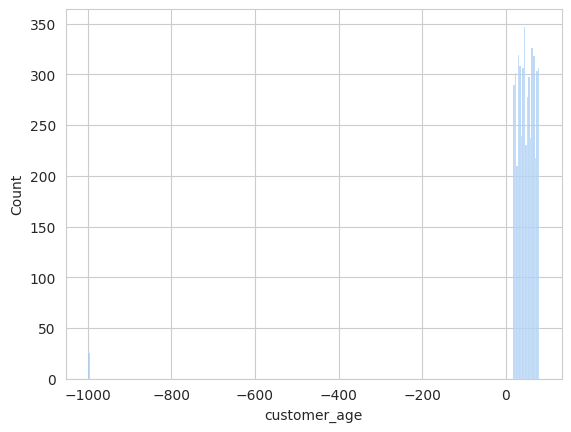

In [ ]:
sns.histplot(data=everpeak_retail,x='customer_age')

<Axes: xlabel='customer_age'>

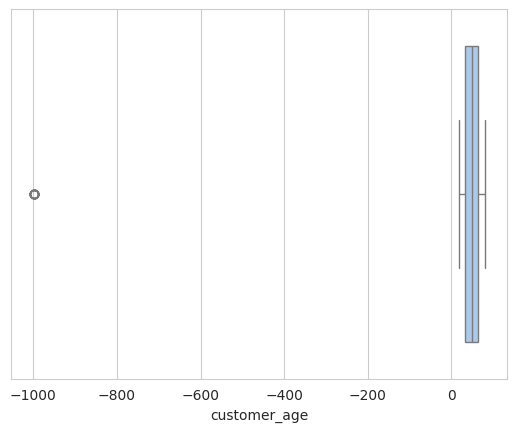

In [ ]:
sns.boxplot(data=everpeak_retail,x='customer_age')

In [ ]:
everpeak_retail['customer_age'] = everpeak_retail['customer_age'].replace(-999,None)

In [ ]:
before = everpeak_retail["customer_age"].mean()

# Creamos "customer_age_med"
everpeak_retail["customer_age_med"] = everpeak_retail["customer_age"].fillna(everpeak_retail["customer_age"].median())
after_med = everpeak_retail["customer_age_med"].mean()

# Creamos "customer_age_mean"
everpeak_retail["customer_age_mean"] = everpeak_retail["customer_age"].fillna(everpeak_retail["customer_age"].mean())
after_mean = everpeak_retail["customer_age_mean"].mean()

print(before)
print(after_med)
print(after_mean)

49.122491206290086
49.11821086261981
49.12249120629009


/tmp/ipykernel_2649/3690872659.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  everpeak_retail["customer_age_med"] = everpeak_retail["customer_age"].fillna(everpeak_retail["customer_age"].median())
/tmp/ipykernel_2649/3690872659.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  everpeak_retail["customer_age_mean"] = everpeak_retail["customer_age"].fillna(everpeak_retail["customer_age"].mean())


<Axes: xlabel='customer_age_med'>

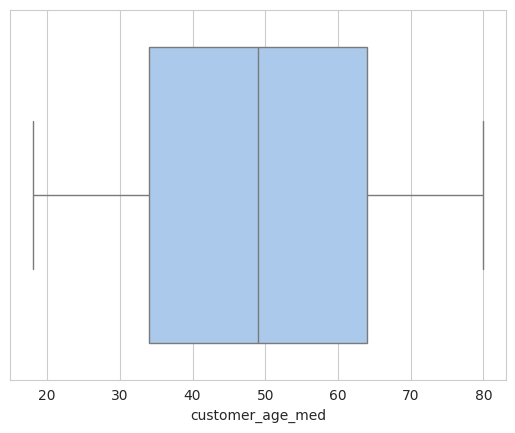

In [ ]:
sns.boxplot(data=everpeak_retail,x='customer_age_med')

In [ ]:
everpeak_retail['city'].value_counts()

,count
city,
Houston,514
Seattle,513
Los Angeles,511
New York,497
Miami,497
Phoenix,491
Chicago,482
Boston,474
San Francisco,468


In [ ]:
everpeak_retail['city']=everpeak_retail['city'].fillna('Houston')

In [ ]:
everpeak_retail['product_category'].value_counts()

,count
product_category,
Fashion,740
Electronics,736
Beauty,721
Toys,719
Sports,704
Grocery,684
Home,679
?,25


In [ ]:
everpeak_retail['product_category']=everpeak_retail['product_category'].replace('?','Unknown')

In [ ]:
everpeak_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           5008 non-null   int64  
 1   order_date         5000 non-null   object 
 2   customer_id        5008 non-null   int64  
 3   product_category   5008 non-null   object 
 4   price              5008 non-null   int64  
 5   quantity           5008 non-null   int64  
 6   order_value        5008 non-null   int64  
 7   payment_method     5008 non-null   object 
 8   city               5008 non-null   object 
 9   state              4908 non-null   object 
 10  customer_age       4833 non-null   object 
 11  customer_age_med   5008 non-null   float64
 12  customer_age_mean  5008 non-null   float64
dtypes: float64(2), int64(5), object(6)
memory usage: 508.8+ KB


### Creación de un *Data pipeline* 🔄📊⚙️

Un pipeline de limpieza es un programa que procesa dato  para su análisis. Su objetivo es ser reutilizable,  sin tener que escribir nuevamente todo el código cada vez que necesites procesar datos nuevos.

<center>
  <img src="https://raw.githubusercontent.com/zyntonyson/img_repo/refs/heads/main/img/08-da-v8-flow-pipeline.png" alt="DataPipeline FlowChart" style="max-width:50%; height:auto;" width="25%">
</center>

#### Aprendamos más sobre python 🐍: *Funciones* 🤖 🧩🛟

En ocasiones necesitamos **reutilizar una misma lógica** muchas veces. Copiar y pegar código no es sostenible 🙅‍♂️, para eso existen las **funciones en Python** 🧩  

🟢 **Funciones (`def`)**  
Se usan cuando queremos **encapsular una tarea**, darle un nombre y **reutilizarla** cuantas veces sea necesario.

**Ventajas clave:**
- Código más limpio ✨  
- Evita duplicaciones ♻️  
- Facilita pruebas y mantenimiento 🛠️  

**Estructura general:**
```python
def nombre_funcion(parametros):
    # código que realiza la tarea
    return resultado
```

> 💡 *Piensa en una función como una máquina: entra algo → se procesa → sale un resultado.*


**Función sin** `return`

In [ ]:
def grettings():
    print("Hello!")

def grettings_with_name(name):
    print(f"Hello {name}!")

In [ ]:
grettings()

Hello!


In [ ]:
grettings_with_name("Laura")

Hello Laura!


In [ ]:
saludo=grettings_with_name('Laura')
print(saludo)

Hello Laura!
None


**Función con** `return`

In [ ]:
def grettings_with_name(name):
    return f"Hello {name}!"

In [ ]:
grettings_with_name("Laura")

'Hello Laura!'

In [ ]:
saludo=grettings_with_name('Laura')
print(saludo)

Hello Laura!


**Funciones para estandarizar texto**

In [ ]:
def cleaning_text(text):
    print(text.strip().lower())

In [ ]:
textos_para_limpiar=[' LuNes ', 'Martes ', 'JUEVES','viernes ']

for texto in textos_para_limpiar:
    cleaning_text(texto)

lunes
martes
jueves
viernes


**Tareas que debe realizar nuestro datapipeline**

- Estandarizar variables
    - Textos: Remover espacios innecesarios, convertir a minúsculas sustituir sentinels y nulos por *unknown*.
    - Númericos: Asegurarse que sean númericos, sustituir sentinels y reemplazar nulos por la media

In [ ]:
def clean_text_columns(df,text_cols):
    sentinels=['?']
    df_copy=df.copy()
    for col in text_cols:
        df_copy[col]=df_copy[col].str.strip().str.lower().str.replace(sentinels,'Unknown').fillna('Unknown')
    return df_copy

In [ ]:
def clean_numeric_columns(df,numeric_cols):
    sentinels=[-999]
    df_copy=df.copy()
    for col in numeric_cols:
        df_copy[col]=pd.to_numeric(df_copy[col])
        df_copy[col] = df_copy[col].replace(sentinels,pd.NA)
        df_copy[col] = df_copy[col].fillna(df_copy[col].mean())
    return df_copy

In [ ]:
everpeak_retail_unclean = pd.read_csv("https://practicum-content.s3.us-west-1.amazonaws.com/datasets/everpeak_retail.csv")

In [ ]:
text_cols=[ 'product_category', 'payment_method', 'city', 'state']
everpeak_retail_clean=clean_text_columns(everpeak_retail_unclean,text_cols)

In [ ]:
numeric_cols=[ 'price', 'customer_age']
everpeak_retail_clean=clean_numeric_columns(everpeak_retail_clean,numeric_cols)

/tmp/ipykernel_2649/36165818.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy[col] = df_copy[col].fillna(df_copy[col].mean())


In [ ]:
everpeak_retail_unclean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5008 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5008 non-null   int64  
 3   product_category  5008 non-null   object 
 4   price             5008 non-null   int64  
 5   quantity          5008 non-null   int64  
 6   order_value       5008 non-null   int64  
 7   payment_method    5008 non-null   object 
 8   city              4908 non-null   object 
 9   state             4908 non-null   object 
 10  customer_age      4858 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 430.5+ KB


In [ ]:
everpeak_retail_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5008 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5008 non-null   int64  
 3   product_category  5008 non-null   object 
 4   price             5008 non-null   int64  
 5   quantity          5008 non-null   int64  
 6   order_value       5008 non-null   int64  
 7   payment_method    5008 non-null   object 
 8   city              5008 non-null   object 
 9   state             5008 non-null   object 
 10  customer_age      5008 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 430.5+ KB


In [ ]:
def pipeline_everpeak_retail():
    text_cols=[ 'product_category', 'payment_method', 'city', 'state']
    numeric_cols=[ 'price', 'customer_age']
    df =  pd.read_csv("https://practicum-content.s3.us-west-1.amazonaws.com/datasets/everpeak_retail.csv")
    df = clean_text_columns(df,text_cols)
    df = clean_numeric_columns(df, numeric_cols)
    df ["order_date"] = pd.to_datetime(df["order_date"],errors="coerce" )
    df.drop_duplicates(inplace=True)
    return df

In [ ]:
everpeak_retail_clean=pipeline_everpeak_retail()

/tmp/ipykernel_2649/36165818.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy[col] = df_copy[col].fillna(df_copy[col].mean())


In [ ]:
everpeak_retail_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5008 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5008 non-null   int64  
 3   product_category  5008 non-null   object 
 4   price             5008 non-null   int64  
 5   quantity          5008 non-null   int64  
 6   order_value       5008 non-null   int64  
 7   payment_method    5008 non-null   object 
 8   city              5008 non-null   object 
 9   state             5008 non-null   object 
 10  customer_age      5008 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 430.5+ KB


## 🚀 Para seguir aprendiendo :

---

- 📚 Vuelve a revisar este notebook y trata resolver por tu cuenta  nuevamente
- 💬 Recuerda que en Discord puedes dejar todos tus comentarios y dudas sobre el contenido del sprint en [`Discord`](https://discord.com/channels/1081207584104656986/1420849538196836472).
    - 📝 Si tienes preguntas sobre tu proyecto, usa el canal [`#project`](https://discord.com/channels/1081207584104656986/1420848813186351134) para recibir ayuda y compartir ideas.
    - 🤝 Aprovecha el espacio de `CoLearning` para aclarar tus dudas junto con otros estudiantes e instructores: [Co-Learning](https://discord.com/channels/1081207584104656986/1197953851391746119).
    - En tus preguntas recuerda etiquetar a `@Dataconsulta` y ubica tu pregunta de acuerdo a `Sprint/Capitulo/Seccion`
- 📅 ¿Necesitas ayuda personalizada? Puedes agendar una sesión `1:1` conmigo aquí: [1:1 Roman Castillo](https://scheduler.zoom.us/roman-castillo/1-1-roman-castillo).

- Por último hazme paro y responde la encuesta al final de la sesión, me sirve para poder ayudarte mejor

¡Sigue practicando y no dudes en pedir apoyo cuando lo necesites! 💪✨